In [9]:
import os
from google.colab import drive

drive.mount('/content/drive')

PROJECT_ROOT = '/content/drive/MyDrive/Colab Notebooks/BD_IA'
OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'outputs')

#数据集存在Colab本地，保证读写速度
DATA_DIR = '/content/data'

#创建输出目录
for d in ["logs", "checkpoints", "figures"]:
    os.makedirs(os.path.join(OUTPUT_DIR, d), exist_ok=True)

print(f"数据保存在: {DATA_DIR} (方便读写)")
print(f"结果保存在: {OUTPUT_DIR} (保存到云盘)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
数据保存在: /content/data (方便读写)
结果保存在: /content/drive/MyDrive/Colab Notebooks/BD_IA/outputs (保存到云盘)


In [10]:
import time, random, csv, json
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from tqdm.notebook import tqdm

BATCH_SIZE = 64
EPOCHS = 20
SEED = 42
NUM_WORKERS = 2
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

#消融实验设置
SUBSET_RATIOS = [0.10, 0.25, 1.00]  # 数据消融
SETTINGS = ["scratch", "transfer_linear", "transfer_finetune"]

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed()
print(f"当前使用设备: {DEVICE}")


#数据集导入与导出
def get_pets_loaders(ratio):
    # ImageNet 标准归一化
    mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

    train_tf = transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(0.2, 0.2, 0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    test_tf = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    # 下载至 /content/data (极快)
    train_ds = datasets.OxfordIIITPet(DATA_DIR, split="trainval", download=True, transform=train_tf)
    test_ds  = datasets.OxfordIIITPet(DATA_DIR, split="test", download=True, transform=test_tf)

    # 抽取子集 (按比例)
    if ratio < 1.0:
        rng = np.random.RandomState(SEED)
        targets = np.array(train_ds._labels)
        classes = np.unique(targets)
        selected = []
        for c in classes:
            idx_c = np.where(targets == c)[0]
            k = max(1, int(len(idx_c) * ratio))
            chosen = rng.choice(idx_c, k, replace=False)
            selected.extend(chosen.tolist())
        rng.shuffle(selected)
        train_ds = Subset(train_ds, selected)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

    return train_loader, test_loader, len(train_ds)


#模型与训练逻辑
def build_experiment(setting):
    weights = models.ResNet18_Weights.IMAGENET1K_V1 if setting != "scratch" else None
    model = models.resnet18(weights=weights)
    model.fc = nn.Linear(model.fc.in_features, 37) # Pets有37类

    if setting == "transfer_linear":
        for name, p in model.named_parameters():
            p.requires_grad = name.startswith("fc.")

    model = model.to(DEVICE)

    # 优化器设计
    if setting == "scratch":
        opt = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
    elif setting == "transfer_linear":
        params = [p for p in model.parameters() if p.requires_grad]
        opt = torch.optim.AdamW(params, lr=1e-3, weight_decay=1e-2)
    else: # finetune (分层学习率)
        backbone, head = [], []
        for n, p in model.named_parameters():
            (head if n.startswith("fc.") else backbone).append(p)
        opt = torch.optim.AdamW([
            {"params": backbone, "lr": 1e-4},
            {"params": head, "lr": 1e-3}
        ], weight_decay=1e-2)

    return model, opt

def train_one_epoch(model, loader, opt, scheduler):
    model.train()
    crit = nn.CrossEntropyLoss(label_smoothing=0.1)
    acc_m, loss_m, n = 0, 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        opt.zero_grad()
        logits = model(x)
        loss = crit(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        opt.step()

        bs = x.size(0)
        loss_m += loss.item() * bs
        acc_m += (logits.argmax(dim=1) == y).float().mean().item() * bs
        n += bs
    if scheduler: scheduler.step()
    return loss_m / n, acc_m / n

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    crit = nn.CrossEntropyLoss()
    acc_m, loss_m, n = 0, 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        bs = x.size(0)
        loss_m += crit(logits, y).item() * bs
        acc_m += (logits.argmax(dim=1) == y).float().mean().item() * bs
        n += bs
    return loss_m / n, acc_m / n

当前使用设备: cuda


In [11]:
#运行主循环
summary = []
total_exps = len(SUBSET_RATIOS) * len(SETTINGS)
current_exp = 0

for ratio in SUBSET_RATIOS:
    train_loader, test_loader, num_train = get_pets_loaders(ratio)
    print(f"\n{'='*50}\n准备数据量: {int(ratio*100)}% (训练样本数: {num_train})\n{'='*50}")

    for setting in SETTINGS:
        current_exp += 1
        name = f"pets_{setting}_r{int(ratio*100):03d}"
        print(f"\n[{current_exp}/{total_exps}] 正在运行: {name}")

        set_seed()
        model, opt = build_experiment(setting)

        # 学习率调度
        if setting == "scratch":
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
        else:
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS) # 简化统一用Cosine

        best_acc = 0.0
        history = []

        pbar = tqdm(range(1, EPOCHS + 1), leave=False)
        for ep in pbar:
            tr_loss, tr_acc = train_one_epoch(model, train_loader, opt, scheduler)
            te_loss, te_acc = evaluate(model, test_loader)

            if te_acc > best_acc:
                best_acc = te_acc
                torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, "checkpoints", f"{name}_best.pth"))

            history.append({"epoch": ep, "train_loss": round(tr_loss,4), "train_acc": round(tr_acc,4),
                            "test_loss": round(te_loss,4), "test_acc": round(te_acc,4), "best_acc": round(best_acc,4)})

            pbar.set_postfix({"te_acc": f"{te_acc:.3f}", "best": f"{best_acc:.3f}"})

        # 保存 CSV
        csv_path = os.path.join(OUTPUT_DIR, "logs", f"{name}.csv")
        with open(csv_path, "w", newline="") as f:
            w = csv.DictWriter(f, fieldnames=history[0].keys())
            w.writeheader()
            w.writerows(history)

        summary.append({"setting": setting, "ratio": ratio, "best_acc": best_acc})

# 保存总览 JSON
with open(os.path.join(OUTPUT_DIR, "logs", "summary.json"), "w") as f:
    json.dump(summary, f, indent=2)
print("\n实验完成，数据已保存至Google Drive")


准备数据量: 10% (训练样本数: 365)

[1/9] 正在运行: pets_scratch_r010


  0%|          | 0/20 [00:00<?, ?it/s]


[2/9] 正在运行: pets_transfer_linear_r010
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 133MB/s]


  0%|          | 0/20 [00:00<?, ?it/s]

...


[8/9] 正在运行: pets_transfer_linear_r100


  0%|          | 0/20 [00:00<?, ?it/s]


[9/9] 正在运行: pets_transfer_finetune_r100


  0%|          | 0/20 [00:00<?, ?it/s]


实验完成，数据已保存至Google Drive


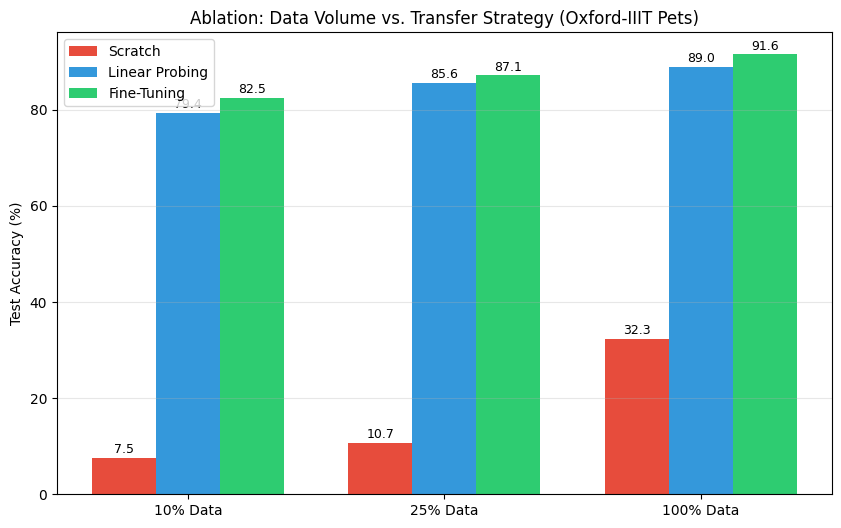


正在可视化失败案例(以100%Fine-Tuning为例)...


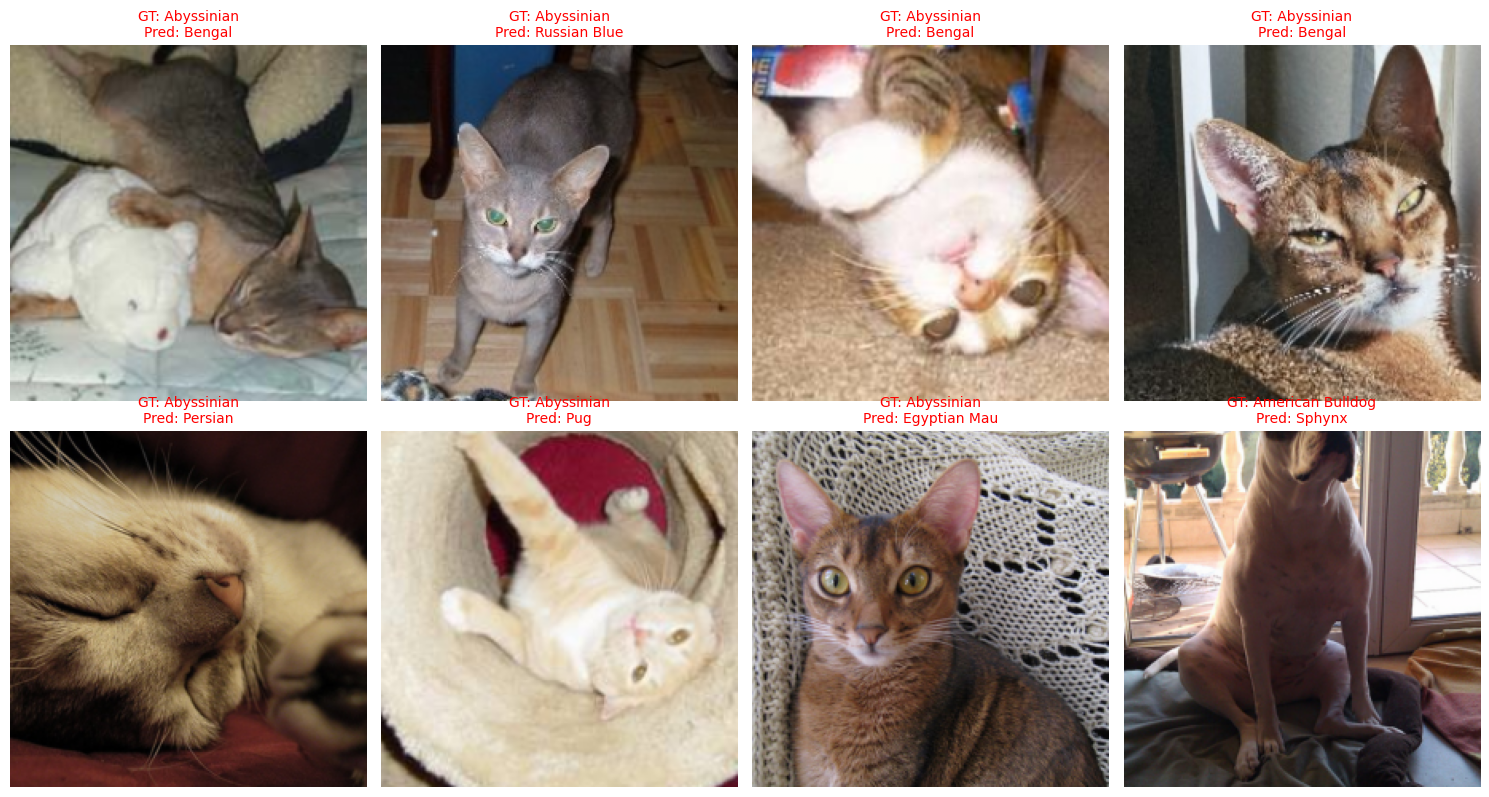

In [12]:
#生成报告所需的图表与可视化
from IPython.display import display

#绘制最佳准确率柱状图
with open(os.path.join(OUTPUT_DIR, "logs", "summary.json")) as f:
    summary_data = json.load(f)

plt.figure(figsize=(10, 6))
colors = {"scratch": "#e74c3c", "transfer_linear": "#3498db", "transfer_finetune": "#2ecc71"}
labels = {"scratch": "Scratch", "transfer_linear": "Linear Probing", "transfer_finetune": "Fine-Tuning"}

x = np.arange(len(SUBSET_RATIOS))
width = 0.25

for i, setting in enumerate(SETTINGS):
    accs = [s["best_acc"]*100 for s in summary_data if s["setting"]==setting]
    bars = plt.bar(x + i*width, accs, width, label=labels[setting], color=colors[setting])
    for bar in bars:
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height()+1, f"{bar.get_height():.1f}", ha='center', fontsize=9)

plt.xticks(x + width, [f"{int(r*100)}% Data" for r in SUBSET_RATIOS])
plt.ylabel("Test Accuracy (%)")
plt.title("Ablation: Data Volume vs. Transfer Strategy (Oxford-IIIT Pets)")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.savefig(os.path.join(OUTPUT_DIR, "figures", "acc_bar_pets.png"), dpi=200, bbox_inches='tight')
plt.show()

#失败案例可视化
print("\n正在可视化失败案例(以100%Fine-Tuning为例)...")
best_setting = "transfer_finetune"
best_model, _ = build_experiment(best_setting)
best_model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, "checkpoints", f"pets_{best_setting}_r100_best.pth")))
best_model.eval()

_, test_loader, _ = get_pets_loaders(1.0)
class_names = datasets.OxfordIIITPet(DATA_DIR, split="test").classes
mean, std = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1), torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

wrong_imgs, wrong_preds, wrong_gts = [], [], []
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        preds = best_model(x).argmax(dim=1)
        mask = preds != y
        wrong_imgs.extend(x[mask].cpu())
        wrong_preds.extend(preds[mask].cpu())
        wrong_gts.extend(y[mask].cpu())
        if len(wrong_imgs) >= 8: break

fig, axes = plt.subplots(2, 4, figsize=(15, 8))
for i, ax in enumerate(axes.flatten()):
    if i < len(wrong_imgs):
        img = (wrong_imgs[i] * std + mean).permute(1, 2, 0).clamp(0, 1).numpy()
        ax.imshow(img)
        ax.set_title(f"GT: {class_names[wrong_gts[i]]}\nPred: {class_names[wrong_preds[i]]}", color="red", fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "figures", "failure_cases.png"), dpi=200)
plt.show()

In [13]:
import torchvision
print(torchvision.__version__)

train_ds = datasets.OxfordIIITPet(DATA_DIR, split="trainval", download=True)
print(dir(train_ds))  # 查看所有属性

0.25.0+cu128
['_RESOURCES', '_VALID_TARGET_TYPES', '__add__', '__annotations__', '__class__', '__class_getitem__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__orig_bases__', '__parameters__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_anns_folder', '_base_folder', '_bin_labels', '_check_exists', '_download', '_format_transform_repr', '_images', '_images_folder', '_labels', '_repr_indent', '_segs', '_segs_folder', '_split', '_target_types', 'bin_class_to_idx', 'bin_classes', 'class_to_idx', 'classes', 'extra_repr', 'root', 'target_transform', 'transform', 'transforms']
